# Imports

In [4]:
pip install lxml

Note: you may need to restart the kernel to use updated packages.


In [5]:
pip install tqdm

Note: you may need to restart the kernel to use updated packages.


In [7]:
from lxml import etree
import pandas as pd
import os
from IPython.display import clear_output
from tqdm import tqdm
from shutil import copyfile
import datetime

# Sélection des séances

Voici deux fonctions qui retiennent la liste des séances ayant un point lié aux VSS dans leur sommaire, ou 3 références au champ lexical des VSS dans leur texte.

In [8]:
def tri_titres(fichier, liste):
    """
        Pour un fichier de débats à l'assemblée, teste s'il a ou non un titre spécifique dans son sommaire.
        input : un nom de fichier .xml au format str et une liste de chaines de caractères
        output : un booléen True si le sommaire comprend une des expressions
    """
    root=etree.parse(fichier).getroot()
    yes=False
    for chaine in liste:
        for titre1 in root.findall("{http://schemas.assemblee-nationale.fr/referentiel}metadonnees/{http://schemas.assemblee-nationale.fr/referentiel}sommaire/{http://schemas.assemblee-nationale.fr/referentiel}sommaire1/{http://schemas.assemblee-nationale.fr/referentiel}titreStruct/{http://schemas.assemblee-nationale.fr/referentiel}intitule"):
            #print(titre1.text)
            if chaine in titre1.text.lower():
                yes=True
                break
        for titre2 in root.findall("{http://schemas.assemblee-nationale.fr/referentiel}metadonnees/{http://schemas.assemblee-nationale.fr/referentiel}sommaire/{http://schemas.assemblee-nationale.fr/referentiel}sommaire1/{http://schemas.assemblee-nationale.fr/referentiel}sommaire2/{http://schemas.assemblee-nationale.fr/referentiel}titreStruct/{http://schemas.assemblee-nationale.fr/referentiel}intitule"):
            #print(titre2.text)
            if titre2.text!=None and chaine in titre2.text.lower():
                yes=True
                break
    return yes
    

In [9]:
def tri_textes(fichier, liste, seuil):
    """
        Pour un fichier de débats à l'assemblée, teste s'il a un certain nombre d'expressions d'une liste renseignée dans le texte.
        input : un nom de fichier .xml au format str, une liste de chaines à tester, un nombre d'occurences à partir duquel on garde le texte
        output : un booléen True si le texte comprend n_occurrences expressions

        attention : l'apostrophe est notée "’" dans les débats
    """
    root=etree.parse(fichier).getroot()
    yes=False
    nb_occurences=0
    for chaine in liste:
        for i in root.findall("{http://schemas.assemblee-nationale.fr/referentiel}contenu/{http://schemas.assemblee-nationale.fr/referentiel}point/{http://schemas.assemblee-nationale.fr/referentiel}paragraphe") + root.findall("{http://schemas.assemblee-nationale.fr/referentiel}contenu/{http://schemas.assemblee-nationale.fr/referentiel}point/{http://schemas.assemblee-nationale.fr/referentiel}interExtraction/{http://schemas.assemblee-nationale.fr/referentiel}paragraphe"):
            if chaine in ''.join(i.findall("{http://schemas.assemblee-nationale.fr/referentiel}texte")[0].itertext()).lower():
                nb_occurences+=1
            
    if nb_occurences >= seuil:
        yes=True
    return yes

In [10]:
# racines de mots pour capturer toutes les déclinaisons (singulier, pluriel, adjectif)
a_tester = [
    "viol", "sexis", "sexuel", "conjugal", "féminicide", "harcèl", 
    "inceste", "agression", "outrage", "parité", "misogyn", 
    "sexe", "genre", "femme", "pédocrim", "pédophil", "prostitu", 
    "proxénét", "mutilation", "mariage forcé", 
    "ivg", "avortement", 
    "discrimination", "stéréotype", "cybersexis", "revenge porn", 
    "me too", "metoo", "balancetonporc", "consentement"
]
liste_pertinente=[] # liste des fichiers contenant les termes de la liste a_tester
seuil=3 # Nombre de termes de la liste à avoir pour garder un texte

In [11]:
# Recherche dans la XVe législature
if os.getcwd() !="/home/onyxia/work/projet_eco_socio/data/CompteRendusXV/":
    os.chdir("/home/onyxia/work/projet_eco_socio/data/CompteRendusXV/")
for file in tqdm(os.scandir()):
    if file.name[-3:]=="xml":
        if tri_titres(file.name, a_tester)==True:
            liste_pertinente.append(file.name)
        if tri_textes(file.name, a_tester, seuil)==True:
            liste_pertinente.append(file.name)

# Recherche dans la XVIe législature
if os.getcwd() !="/home/onyxia/work/projet_eco_socio/data/CompteRendusXVI/":
    os.chdir("/home/onyxia/work/projet_eco_socio/data/CompteRendusXVI/")
for file in tqdm(os.scandir()):
    if file.name[-3:]=="xml":
        if tri_titres(file.name, a_tester)==True:
            liste_pertinente.append(file.name)
        if tri_textes(file.name, a_tester, seuil)==True:
            liste_pertinente.append(file.name)


    # Recherche dans la XVIIe législature
if os.getcwd() !="/home/onyxia/work/projet_eco_socio/data/CompteRendusXVII/":
    os.chdir("/home/onyxia/work/projet_eco_socio/data/CompteRendusXVII/")
for file in tqdm(os.scandir()):
    if file.name[-3:]=="xml":
        if tri_titres(file.name, a_tester)==True:
            liste_pertinente.append(file.name)
        if tri_textes(file.name, a_tester, seuil)==True:
            liste_pertinente.append(file.name)

liste_pertinente=list(set(liste_pertinente)) # on enlève les doublons

1564it [01:58, 13.19it/s]
605it [01:03,  9.60it/s]
365it [00:36,  9.93it/s]


In [11]:
# Nombre de séances retenues
len(liste_pertinente)

1392

## Ajout des séances retenues dans un dossier séparé

In [12]:
# XVe législature
if os.getcwd() !="/home/onyxia/work/projet_eco_socio/data/CompteRendusXV/":
    os.chdir("/home/onyxia/work/projet_eco_socio/data/CompteRendusXV/")
for file in tqdm(os.scandir()):
    if file.name in liste_pertinente:
        copyfile(file.name, "/home/onyxia/work/projet_eco_socio/sorted/xv/" + file.name)

# XVIe législature
if os.getcwd() !="/home/onyxia/work/projet_eco_socio/data/CompteRendusXVI/":
    os.chdir("/home/onyxia/work/projet_eco_socio/data/CompteRendusXVI/")
for file in tqdm(os.scandir()):
    if file.name in liste_pertinente:
        copyfile(file.name, "/home/onyxia/work/projet_eco_socio/sorted/xvi/" + file.name)

# XVe législature
if os.getcwd() !="/home/onyxia/work/projet_eco_socio/data/CompteRendusXVII/":
    os.chdir("/home/onyxia/work/projet_eco_socio/data/CompteRendusXVII/")
for file in tqdm(os.scandir()):
    if file.name in liste_pertinente:
        copyfile(file.name, "/home/onyxia/work/projet_eco_socio/sorted/xvii/" + file.name)

1564it [00:01, 1456.25it/s]
605it [00:00, 1124.68it/s]
365it [00:00, 1285.56it/s]


Objectif : pour chaque document traité, obtenir le sommaire. Cela permet de trier entre les documents qui abordent des thématiques qui nous intéressent (les violences sexistes et sexuelles) et ceux qui n'ont pas d'intérêt dans notre analyse.

# Parsing des débats à l'Assemblée Nationale

La fonction ci-dessous crée un dataframe regroupant les textes des débats, avec quelques informations complémentaires (date, législature...) et les id des députés. Il est possible qu'elle ne parse pas parfaitement tous les débats, mais on peut rajouter des chemins dans la boucle for pour compléter les manques.

In [14]:
def parsing_debats(fichier):
    """
        Parse un fichier .xml de débats à l'Assemblée Nationale et crée un dataframe des prises de paroles, avec quelques informations complémentaires.
        input : un fichier.xml
        output : un dataframe Pandas
    """
    tree = etree.parse(fichier)
    root = tree.getroot()
    adresse = "{http://schemas.assemblee-nationale.fr/referentiel}"
    
    # Au lieu d'un DataFrame vide, on utilise une liste
    data_list = []
    
    # On récupère les infos communes à tout le fichier une seule fois
    uid_seance = root.findall(adresse + "uid")[0].text
    date_brute = root.findall(adresse + "metadonnees/" + adresse + "dateSeance")[0].text[:8]
    date_seance = pd.to_datetime(date_brute)
    legis = root.findall(adresse + "metadonnees/" + adresse + "legislature")[0].text

    # Ta boucle de recherche de paragraphes
    chemins = [
        adresse + "contenu/" + adresse + "point/" + adresse + "interExtraction/",
        adresse + "contenu/" + adresse + "point/" + adresse + "point/" + adresse + "interExtraction/",
        adresse + "contenu/" + adresse + "point/" + adresse + "paragraphe"
    ]
    
    nodes = []
    for chemin in chemins:
        nodes.extend(root.findall(chemin))

    for i in nodes:
        # Nettoyage du texte (ton code précédent)
        parts = []
        for j in i.findall(adresse + "texte"):
            if j.text: parts.append(j.text)
            for child in j:
                if not child.tag.endswith("italique") and child.text:
                    parts.append(child.text)
                if child.tail: parts.append(child.tail)
        
        texte_final = "".join(parts).replace("\xa0", " ")

        # On ajoute un dictionnaire à notre liste
        data_list.append({
            "seanceRef": uid_seance,
            "ordre_absolu_seance": i.get("ordre_absolu_seance"),
            "date": date_seance,
            "legislature": legis,
            "id_acteur": i.get("id_acteur"),
            "code_grammaire": i.get("code_grammaire"),
            "texte": texte_final
        })

    # On crée le DataFrame d'un seul coup à la fin (Plus de Warning !)
    df = pd.DataFrame(data_list)
    if not df.empty:
        df["ordre_absolu_seance"] = pd.to_numeric(df["ordre_absolu_seance"])
        df = df.sort_values(by="ordre_absolu_seance")
    
    return df

# Parsing des députés et partis politiques

On sélectionne les députés des 3 législatures qui nous intéressent, et leur appartenance politique.

In [15]:
adresse = "{http://schemas.assemblee-nationale.fr/referentiel}"

Les cellules suivantes ont été exécutées en local pour éviter d'importer des milliers de fichiers. Les résultats (fichiers des partis et des députés) sont disponibles dans les dossiers "partis" et "deputes".

In [16]:
# Tri des partis parmi les organes
os.chdir("/home/onyxia/work/projet_eco_socio/organes/")

for file in tqdm(os.scandir()):
    if file.name[-3:]=="xml":
        tree=etree.parse(file.name)
        root=tree.getroot()
        if root.findall(adresse + "codeType")[0].text=="PARPOL":
            copyfile(file.name, "/home/onyxia/work/projet_eco_socio/partis/" + file.name)


FileNotFoundError: [Errno 2] No such file or directory: '/home/onyxia/work/projet_eco_socio/organes/'

In [17]:
# Tri des législatures de l'Assemblée parmi les organes 
os.chdir("/home/onyxia/work/projet_eco_socio/organes/")

for file in tqdm(os.scandir()):
    if file.name[-3:]=="xml":
        tree=etree.parse(file.name)
        root=tree.getroot()
        if root.findall(adresse + "codeType")[0].text=="ASSEMBLEE":
            copyfile(file.name, "/home/onyxia/work/projet_eco_socio/assemblee/" + file.name)


FileNotFoundError: [Errno 2] No such file or directory: '/home/onyxia/work/projet_eco_socio/organes/'

In [18]:
# Tri des députés parmi les acteurs
os.chdir("/home/onyxia/work/projet_eco_socio/acteur")
liste_legislatures=["PO791932", "PO838901", "PO717460"]

for file in os.scandir():
    if file.name[-3:]=="xml":
        tree=etree.parse(file.name)
        root=tree.getroot()
        for i in root.findall(adresse + "mandats/" + adresse + "mandat/" + adresse + "organes/" + adresse + "organeRef"):
            if i.text in liste_legislatures:
                copyfile(file.name, "/home/onyxia/work/projet_eco_socio/deputes/" + file.name)
                break

FileNotFoundError: [Errno 2] No such file or directory: '/home/onyxia/work/projet_eco_socio/acteur'

In [19]:
# DF des partis politiques
os.chdir("/home/onyxia/work/projet_eco_socio/partis/")
df_partis=pd.DataFrame({"parti":[], "nom_parti":[]})
df_partis["parti"]=df_partis["parti"].astype("str")

k=0
for file in tqdm(os.scandir()):
    if file.name[-3:]=="xml":
        tree=etree.parse(file.name)
        root=tree.getroot()
        df_partis.loc[k, "parti"]=root.findall(adresse + "uid")[0].text
        df_partis.loc[k, "nom_parti"]=root.findall(adresse + "libelle")[0].text
        k+=1


df_partis["parti"]=df_partis["parti"].astype("str")


0it [00:00, ?it/s]/tmp/ipykernel_5003/346939273.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Mouvement Indépendantiste Martiniquais' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_partis.loc[k, "nom_parti"]=root.findall(adresse + "libelle")[0].text
58it [00:00, 1124.87it/s]


In [20]:
# DF des députés
os.chdir("/home/onyxia/work/projet_eco_socio/deputes")
df_deputes=pd.DataFrame({"id_acteur":[], "nom":[], "prenom":[], "parti":[], "debut":[]})
df_deputes["parti"]=df_deputes["parti"].astype("str")

k=0
for file in os.scandir():
    tree=etree.parse(file.name)
    root=tree.getroot()
    for i in root.findall(adresse + "mandats/" + adresse + "mandat"):
        if i.findall(adresse + "typeOrgane")[0].text=="PARPOL":
            df_deputes.loc[k, "id_acteur"]=root.findall(adresse + "uid")[0].text
            df_deputes.loc[k, "nom"]=root.findall(adresse + "etatCivil/" + adresse + "ident/" + adresse + "nom")[0].text
            df_deputes.loc[k, "prenom"]=root.findall(adresse + "etatCivil/" + adresse + "ident/" + adresse + "prenom")[0].text
            df_deputes.loc[k, "parti"]=i.findall(adresse + "organes/" + adresse + "organeRef")[0].text
            df_deputes.loc[k, "debut"]=i.findall(adresse + "dateDebut")[0].text
            k+=1

df_deputes["parti"]=df_deputes["parti"].astype("str")
df_deputes["debut"]=pd.to_datetime(df_deputes["debut"])

/tmp/ipykernel_5003/1193967353.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'PA794658' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_deputes.loc[k, "id_acteur"]=root.findall(adresse + "uid")[0].text
/tmp/ipykernel_5003/1193967353.py:13: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Fait' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_deputes.loc[k, "nom"]=root.findall(adresse + "etatCivil/" + adresse + "ident/" + adresse + "nom")[0].text
/tmp/ipykernel_5003/1193967353.py:14: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Philippe' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_deputes.loc[k, "pre

OSError: Error reading file '.ipynb_checkpoints': Is a directory

In [ ]:
df_deputes=df_deputes.merge(df_partis, on="parti")

In [ ]:
df_deputes.to_csv("/home/onyxia/work/projet_eco_socio/dataframes/df_deputes.csv")

# Ajout des partis dans les dataframes des débats

Ici, on reprend la fonction créée précédemment pour générer le dataframe des discussions d'une séance. Pour chaque prise de parole, on joint le nom du député et son parti au moment de la séance.

In [ ]:
# Tests avec une séance au hasard
df_test=parsing_debats("/home/onyxia/work/projet_eco_socio/sorted/xvi/CRSANR5L16S2023O1N078.xml")

In [21]:
def ajouter_partis(df_debats, df_deputes):
    """
        Joint un dataframe représentant une séance de débats avec les partis politiques des députés au moment de la séance.
    """
    # on s'assure que la date de la séance est bien un objet Date
    date_seance = pd.to_datetime(df_debats.loc[0, "date"])

    # on filtre les députés présents
    concernes = df_deputes[df_deputes["id_acteur"].isin(df_debats["id_acteur"])].copy()
    
    # on force la colonne 'debut' en datetime juste avant la comparaison
    concernes["debut"] = pd.to_datetime(concernes["debut"], errors='coerce')
    
    # on compare (maintenant les deux côtés sont des Timestamps)
    # on garde que les mandats qui ont commencé AVANT ou LE JOUR de la séance
    concernes = concernes[concernes["debut"] <= date_seance]

    # on garde le mandat le plus récent pour chaque député
    concernes = concernes.sort_values("debut", ascending=False).drop_duplicates(subset="id_acteur", keep="first")

    
    df_debats = df_debats.merge(concernes[["parti", "nom_parti", "id_acteur"]], on="id_acteur", how="left")
    
    return df_debats
    
    

In [22]:
print(df_deputes.columns)

Index(['id_acteur', 'nom', 'prenom', 'parti', 'debut'], dtype='object')


In [23]:
#  on s'assure que les deux dataframes utilisent des chaînes de caractères pour la clé 'parti'
df_deputes["parti"] = df_deputes["parti"].astype(str)
df_partis["parti"] = df_partis["parti"].astype(str)

#  merge ET on l'assigne à df_deputes
df_deputes = df_deputes.merge(df_partis, on="parti", how="left")


print("Nouvelles colonnes :", df_deputes.columns.tolist())

Nouvelles colonnes : ['id_acteur', 'nom', 'prenom', 'parti', 'debut', 'nom_parti']


In [24]:
all_seances = []
dossiers = ["xv", "xvi", "xvii"]

for leg in dossiers:
    chemin = f"/home/onyxia/work/projet_eco_socio/sorted/{leg}/"
    
    # vérification si le dossier existe vraiment
    if not os.path.exists(chemin):
        print(f"Le dossier {chemin} n'existe pas.")
        continue

    for file in tqdm(os.scandir(chemin), desc=f"Parsing {leg}"):
        if file.name.endswith(".xml"):
            try:
                # 1. parsing du fichier
                df_temp = parsing_debats(file.path)
                
                # vérification : si le dataframe est vide, on passe au suivant
                if df_temp.empty:
                    continue
                
                # 2. ajout des partis
                df_temp = ajouter_partis(df_temp, df_deputes)
                
                # on ne garde que si le merge a fonctionné et qu'il reste des données
                if not df_temp.empty:
                    all_seances.append(df_temp)
                    
            except Exception as e:
                # Ici on affiche l'erreur pour comprendre pourquoi ça rate sur ce fichier
                print(f"Erreur sur le fichier {file.name} : {e}")
                continue

# sécurité avant de concaténer
if len(all_seances) > 0:
    df_global = pd.concat(all_seances, ignore_index=True)
    print(f"Succès : {len(df_global)} prises de parole récupérées.")
else:
    print("Erreur : Aucun fichier n'a pu être traité. Vérifie tes chemins ou tes fonctions.")

Parsing xv: 792it [00:19, 40.06it/s]
Parsing xvi: 381it [00:13, 28.41it/s]
Parsing xvii: 220it [00:07, 30.98it/s]


Succès : 542004 prises de parole récupérées.


In [25]:
# on crée une expression régulière à partir de la liste de mots-clés
pattern = '|'.join(a_tester)

# on filtre : on ne garde que les lignes qui contiennent un de ces mots
df_vss = df_global[df_global['texte'].str.contains(pattern, case=False, na=False)].copy()

In [26]:
output_dir = "/home/onyxia/work/projet_eco_socio/analyses_par_partis/"
os.makedirs(output_dir, exist_ok=True)

# on groupe par le nom du parti
for parti, group in df_vss.groupby("nom_parti"):
    # nettoyage du nom du parti pour le nom de fichier
    nom_propre = "".join(x for x in parti if x.isalnum() or x in "._- ").strip()
    
    with open(f"{output_dir}{nom_propre}.txt", "w", encoding="utf-8") as f:
        # on écrit chaque prise de parole dans le fichier
        for discours in group["texte"]:
            f.write(discours + "\n\n---\n\n")

print(f"Documents créés pour {len(df_vss['nom_parti'].unique())} partis.")

Documents créés pour 44 partis.


test


/tmp/ipykernel_5003/528758609.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vss_counts.values, y=vss_counts.index, palette="viridis")


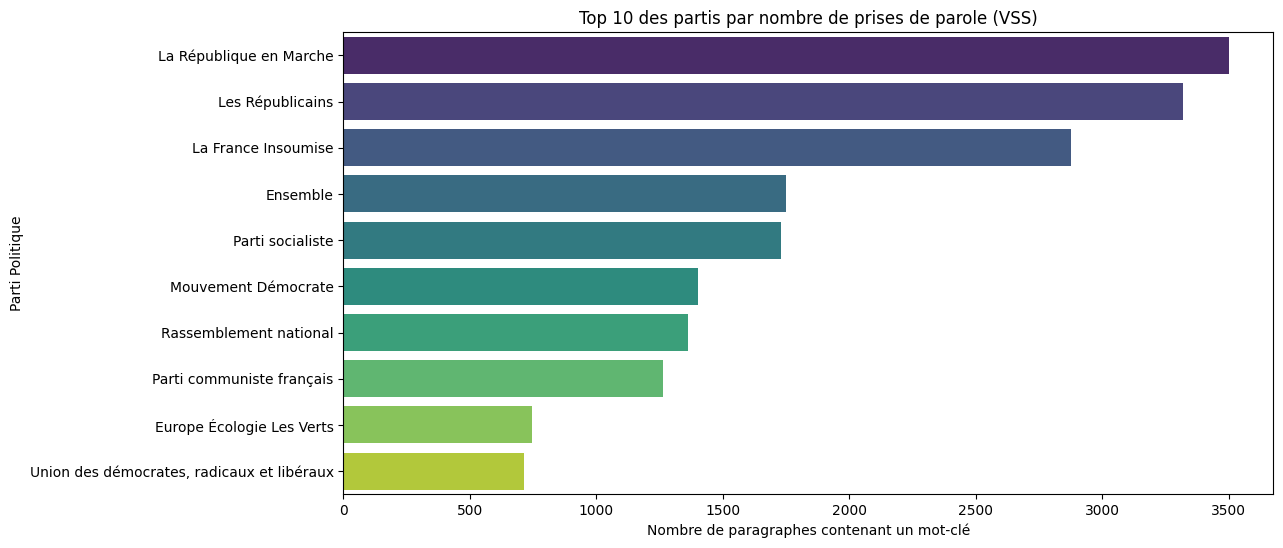

test 2


In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

print("test")
# on s'assure d'avoir notre dataframe filtré avec uniquement les lignes "VSS"
pattern = '|'.join(a_tester)
df_vss = df_global[df_global['texte'].str.contains(pattern, case=False, na=False)].copy()

# Calcul du nombre de prises de parole par parti
vss_counts = df_vss['nom_parti'].value_counts().head(10) # Top 10 des partis

plt.figure(figsize=(12, 6))
sns.barplot(x=vss_counts.values, y=vss_counts.index, palette="viridis")
plt.title("Top 10 des partis par nombre de prises de parole (VSS)")
plt.xlabel("Nombre de paragraphes contenant un mot-clé")
plt.ylabel("Parti Politique")
plt.show()

print("test 2")

/tmp/ipykernel_5003/2531510810.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  evolution = df.resample('M', on='date').size()


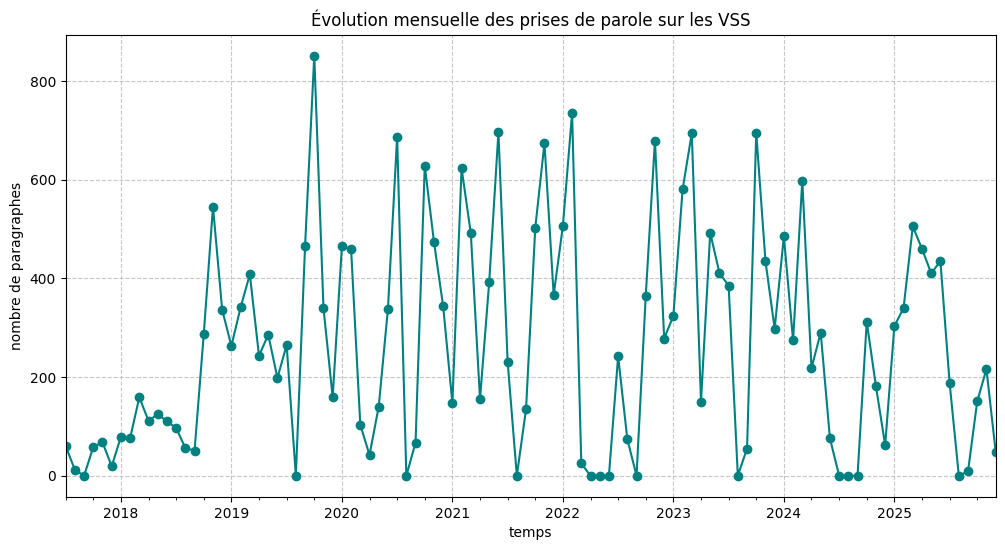

test


In [32]:
def tracer_evolution_vss(df):
    ''' affiche le nombre de prises de parole par mois sur les vss '''
    # on groupe les données par mois et on compte les lignes
    evolution = df.resample('M', on='date').size()
    
    # création du graphique
    plt.figure(figsize=(12, 6))
    evolution.plot(kind='line', marker='o', color='teal')
    plt.title("Évolution mensuelle des prises de parole sur les VSS")
    # on retire la majuscule par habitude ici aussi
    plt.xlabel("temps")
    plt.ylabel("nombre de paragraphes")
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

tracer_evolution_vss(df_vss)
print("test")

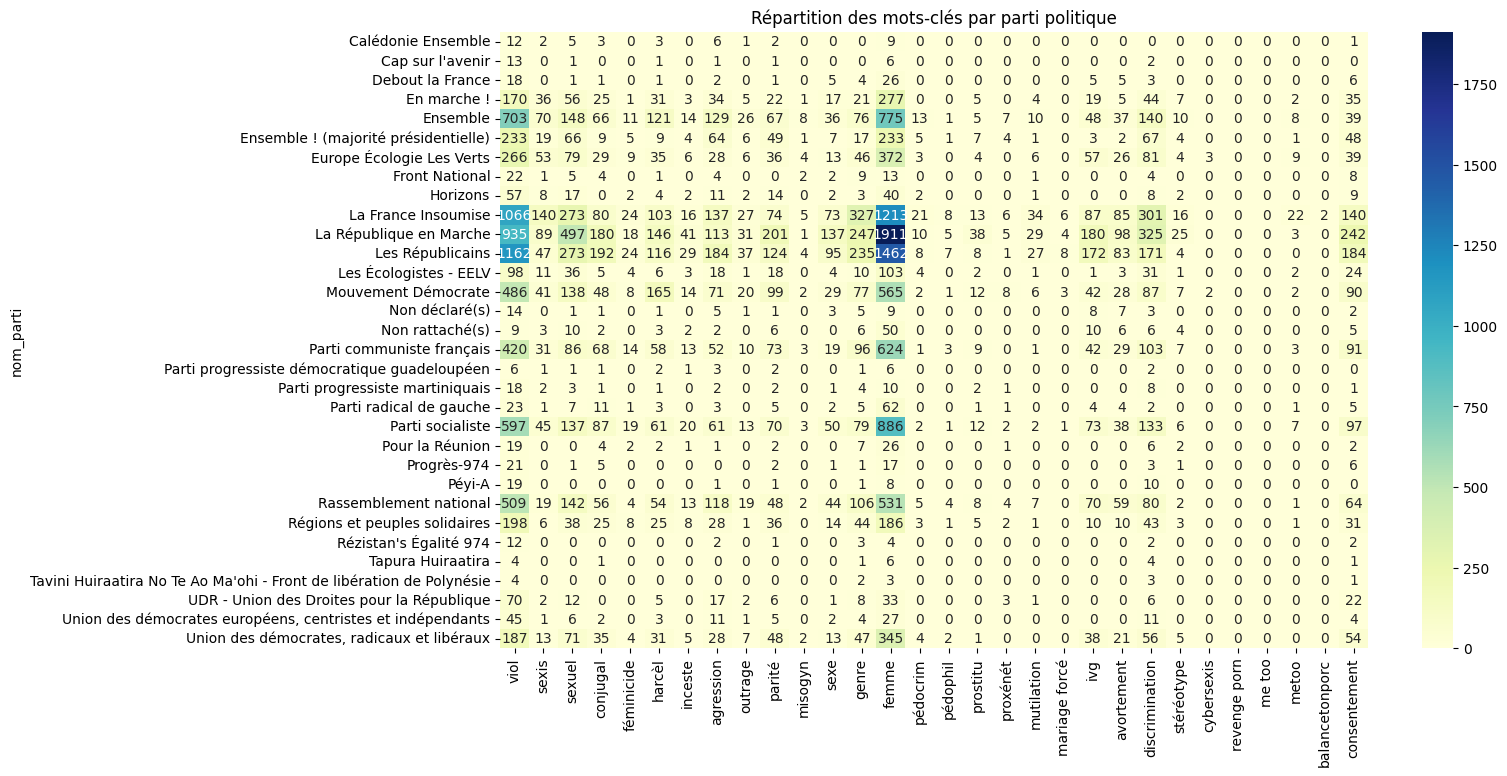

In [28]:
# on crée une colonne pour chaque mot-clé pour voir s'il est présent
for mot in a_tester:
    df_vss[mot] = df_vss['texte'].str.contains(mot, case=False, na=False)

# on regroupe par parti et on fait la somme des détections
heatmap_data = df_vss.groupby('nom_parti')[a_tester].sum()

# on ne garde que les partis qui ont au moins 10 mentions au total pour la lisibilité
heatmap_data = heatmap_data[heatmap_data.sum(axis=1) > 10]

plt.figure(figsize=(14, 8))
sns.heatmap(heatmap_data, annot=True, cmap="YlGnBu", fmt='g')
plt.title("Répartition des mots-clés par parti politique")
plt.show()

In [34]:
import re
from collections import Counter
import nltk
from nltk.corpus import stopwords

# téléchargement des mots outils si nécessaire
nltk.download('stopwords')
stop_words_french = stopwords.words('french')

def analyser_cadrage_mot(df, mot_cible, stop_words):
    ''' regarde quels mots sont utilisés dans un rayon de 10 mots autour d'un concept clé '''
    # on initialise le dictionnaire de résultats
    resultats = {}
    
    for parti in df['nom_parti'].unique():
        # gestion des valeurs nulles pour éviter les plantages
        if pd.isna(parti): continue
            
        textes_parti = df[df['nom_parti'] == parti]['texte'].str.lower().tolist()
        mots_autour = []
        
        for t in textes_parti:
            # on découpe le texte en mots
            segments = re.split(r'\W+', t)
            if mot_cible in segments:
                # on trouve l'emplacement du mot cible
                idx = segments.index(mot_cible)
                # on définit la fenêtre de 10 mots avant et après
                fenetre = segments[max(0, idx-10):idx] + segments[idx+1:idx+11]
                # on filtre les mots inutiles et trop courts
                mots_autour.extend([m for m in fenetre if m not in stop_words and len(m) > 3])
        
        if mots_autour:
            # on ne garde que les 5 mots les plus fréquents
            top_mots = [m for m, c in Counter(mots_autour).most_common(5)]
            resultats[parti] = top_mots
            
    for parti, mots in resultats.items():
        print(f"autour de '{mot_cible}' chez {parti} : {', '.join(mots)}")

# enrichissement manuel de la liste pour nettoyer le bruit parlementaire
mots_a_exclure = [
    "plus", "cette", "faire", "tout", "être", "bien", "comme", "aussi", 
    "fait", "tous", "entre", "leurs", "ceux", "celles", "sans", "dire",
    "ils", "elles", "sous", "vers", "notre", "votre", "leurs", "dont", "puis"
]
stop_words_french.extend(mots_a_exclure)

# lancement de l'analyse
analyser_cadrage_mot(df_vss, "féminicide", stop_words_french)

[nltk_data] Downloading package stopwords to /home/onyxia/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


🔍 autour de 'féminicide' chez Mouvement Démocrate : défenestrée, reconnaissant, caractère, antisémite, cour
🔍 autour de 'féminicide' chez La République en Marche : aide, sociale, enfance, encore, grâce
🔍 autour de 'féminicide' chez Les Républicains : longtemps, restera, année, collègues, femme
🔍 autour de 'féminicide' chez La France Insoumise : amendement, vise, étendre, protocole, actuellement
🔍 autour de 'féminicide' chez Parti socialiste : question, dernier, suite, commis, marne
🔍 autour de 'féminicide' chez Parti communiste français : seine, saint, denis, afin, prise
🔍 autour de 'féminicide' chez Rassemblement national : loin, catégorie, fourre, conjoint, partenaire
🔍 autour de 'féminicide' chez En marche ! : veut, connaître, hécatombe, conjugale, peut
🔍 autour de 'féminicide' chez Régions et peuples solidaires : trentième, depuis, appelons, ainsi, victime
🔍 autour de 'féminicide' chez Europe Écologie Les Verts : compagne, mesures, nouvelles, faisons, france
🔍 autour de 'féminicide

In [35]:
def agreger_discours(df, granularite='Y'):
    ''' crée un document unique par parti et par période temporelle '''
    # on s'assure que la date est au bon format
    df['date'] = pd.to_datetime(df['date'])
    
    # on crée une colonne période (ex: 2022)
    df['periode'] = df['date'].dt.to_period(granularite).astype(str)
    
    # on regroupe les textes : on joint tous les paragraphes d'un parti pour une année
    df_docs = df.groupby(['nom_parti', 'periode'])['texte'].apply(lambda x: ' '.join(x)).reset_index()
    
    return df_docs

# on génère nos documents annuels
df_annuel = agreger_discours(df_vss, 'Y')

In [36]:
import nltk
from nltk.stem.snowball import FrenchStemmer
import re

stemmer = FrenchStemmer()

def pre_processing_recherche(texte, stop_words, mots_vss):
    ''' nettoie le texte, stemme, et retire les mots-clés vss pour éviter le biais '''
    # 1. mise en minuscule et retrait de la ponctuation
    texte = re.sub(r'\W+', ' ', texte.lower())
    
    # 2. découpage en mots (tokenization)
    mots = texte.split()
    
    # 3. filtrage : on retire les stop words ET les mots racines de ta liste vss
    # on utilise le stemming pour que 'viol' retire aussi 'viols' ou 'violenté'
    mots_nettoyes = [
        stemmer.stem(m) for m in mots 
        if m not in stop_words 
        and not any(vss in m for vss in mots_vss) # retrait des mots vss
        and len(m) > 2
    ]
    
    return " ".join(mots_nettoyes)

# exécution du nettoyage
df_annuel['texte_clean'] = df_annuel['texte'].apply(lambda x: pre_processing_recherche(x, stop_words_french, a_tester))
print("c'est bon xd")

c'est bon xd


In [37]:
pip install gensim

Note: you may need to restart the kernel to use updated packages.


In [38]:
from gensim import corpora, models

def preparer_corpus_lda(df_clean):
    ''' transforme les textes nettoyés en dictionnaire et en corpus exploitable par gensim '''
    # on transforme chaque document en liste de mots
    textes = [doc.split() for doc in df_clean['texte_clean']]
    
    # on crée le dictionnaire (id -> mot)
    dictionnaire = corpora.Dictionary(textes)
    
    # on crée le corpus (sac de mots : id du mot, fréquence)
    corpus = [dictionnaire.doc2bow(text) for text in textes]
    
    return dictionnaire, corpus

# exécution
dictionnaire, corpus = preparer_corpus_lda(df_annuel)

In [41]:
def entrainer_lda(corpus, dictionnaire, num_topics=5):
    ''' entraîne le modèle lda pour identifier les thématiques majeures '''
    # entraînement du modèle
    # l'erreur venait de l'oubli du '=' pour id2word
    lda_model = models.LdaModel(corpus=corpus, 
                                id2word=dictionnaire, 
                                num_topics=num_topics, 
                                passes=15, 
                                random_state=42)
    
    return lda_model

def afficher_topics(lda_model):
    ''' affiche les mots les plus importants pour chaque thématique découverte '''
    # on parcourt les topics créés
    for i, topic in lda_model.print_topics(-1):
        # on affiche l'id du topic et ses mots clés
        print(f"thématique #{i}: {topic}")

# exécution
lda = entrainer_lda(corpus, dictionnaire)
afficher_topics(lda)


thématique #0: 0.006*"loi" + 0.005*"enfant" + 0.005*"franc" + 0.004*"cel" + 0.004*"égal" + 0.004*"amend" + 0.003*"autr" + 0.003*"état" + 0.003*"contr" + 0.003*"droit"
thématique #1: 0.006*"loi" + 0.005*"text" + 0.005*"enfant" + 0.004*"franc" + 0.004*"droit" + 0.004*"articl" + 0.003*"état" + 0.003*"cel" + 0.003*"disposit" + 0.003*"premi"
thématique #2: 0.005*"droit" + 0.005*"loi" + 0.004*"social" + 0.004*"franc" + 0.004*"autr" + 0.004*"person" + 0.004*"état" + 0.003*"égal" + 0.003*"amend" + 0.003*"cel"
thématique #3: 0.007*"franc" + 0.006*"droit" + 0.005*"loi" + 0.004*"enfant" + 0.004*"état" + 0.004*"cel" + 0.004*"person" + 0.004*"contr" + 0.003*"polit" + 0.003*"social"
thématique #4: 0.007*"loi" + 0.006*"droit" + 0.005*"franc" + 0.004*"text" + 0.004*"proposit" + 0.004*"social" + 0.004*"contr" + 0.004*"group" + 0.004*"cel" + 0.003*"autr"


In [42]:
# on récupère la base
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
stop_words_french = stopwords.words('french')

# on ajoute le bruit institutionnel et les mots vides restants
bruit_parlementaire = [
    "loi", "droit", "état", "amend", "articl", "text", "group", "cel", "autr", 
    "person", "social", "polit", "publi", "cette", "premier", "monsieur", 
    "madame", "président", "ministre", "député", "collègue", "assemblée",
    "proposit", "disposit", "cadre", "mesur", "moyen", "question", "rapport",
    "commission", "gouvern", "souhait", "permettr", "faut", "doit", "peut",
    "bien", "fait", "être", "avoir", "plus", "tout", "tous", "faire"
]
stop_words_french.extend(bruit_parlementaire)

[nltk_data] Downloading package stopwords to /home/onyxia/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [44]:
def nettoyer_et_preparer(df, stop_words, mots_vss):
    ''' nettoie les textes en profondeur et prépare le dictionnaire/corpus pour gensim '''
    # on applique le pre-processing (on réutilise ta fonction précédente)
    df['texte_lda'] = df['texte'].apply(lambda x: pre_processing_recherche(x, stop_words, mots_vss))
    
    # préparation pour gensim
    textes = [doc.split() for doc in df['texte_lda']]
    dictionnaire = corpora.Dictionary(textes)
    
    # on filtre les mots trop rares ou trop fréquents (plus de 50% des docs)
    dictionnaire.filter_extremes(no_below=2, no_above=0.5)
    
    corpus = [dictionnaire.doc2bow(text) for text in textes]
    return dictionnaire, corpus

def entrainer_lda_final(corpus, dictionnaire, num_topics=5):
    ''' entraîne le modèle lda sur le corpus nettoyé '''
    # on augmente un peu les passes pour plus de précision
    model = models.LdaModel(corpus=corpus, 
                            id2word=dictionnaire, 
                            num_topics=num_topics, 
                            passes=20, 
                            random_state=42)
    return model

# exécution
dictionnaire, corpus = nettoyer_et_preparer(df_annuel, stop_words_french, a_tester)
lda = entrainer_lda_final(corpus, dictionnaire)
afficher_topics(lda)

/opt/python/lib/python3.13/site-packages/gensim/models/ldamodel.py:723: RuntimeWarning: invalid value encountered in dot
  phinorm = np.dot(expElogthetad, expElogbetad) + epsilon


thématique #0: 0.003*"sag" + 0.002*"apparent" + 0.002*"délégu" + 0.002*"sport" + 0.002*"enfanc" + 0.002*"vaccin" + 0.002*"défavor" + 0.002*"revaloris" + 0.002*"parental" + 0.002*"grossess"
thématique #1: 0.008*"coupl" + 0.005*"filiat" + 0.004*"pma" + 0.003*"secrétair" + 0.003*"per" + 0.003*"polici" + 0.003*"crédit" + 0.002*"ordon" + 0.002*"parental" + 0.002*"donneur"
thématique #2: 0.003*"polici" + 0.002*"allez" + 0.002*"gen" + 0.002*"coupl" + 0.002*"insoumis" + 0.002*"pension" + 0.002*"emmanuel" + 0.002*"secrétair" + 0.002*"sag" + 0.002*"argent"
thématique #3: 0.005*"impôt" + 0.003*"secrétair" + 0.003*"crédit" + 0.002*"tax" + 0.002*"sang" + 0.002*"achat" + 0.002*"partiel" + 0.002*"militair" + 0.002*"téléphon" + 0.002*"sport"
thématique #4: 0.004*"2023" + 0.003*"2024" + 0.003*"mayott" + 0.002*"rassembl" + 0.002*"antisémit" + 0.002*"ukrain" + 0.002*"russ" + 0.002*"immigr" + 0.002*"2025" + 0.002*"gauch"


In [45]:
def filtrer_docs_vides(df):
    ''' supprime les lignes où le texte nettoyé est vide après filtrage '''
    # on ne garde que les lignes où il reste au moins un mot
    df_clean = df[df['texte_lda'].str.strip() != ""].copy()
    return df_clean

# on nettoie avant de calculer les poids
df_annuel = filtrer_docs_vides(df_annuel)

/opt/python/lib/python3.13/site-packages/gensim/models/ldamodel.py:723: RuntimeWarning: invalid value encountered in dot
  phinorm = np.dot(expElogthetad, expElogbetad) + epsilon


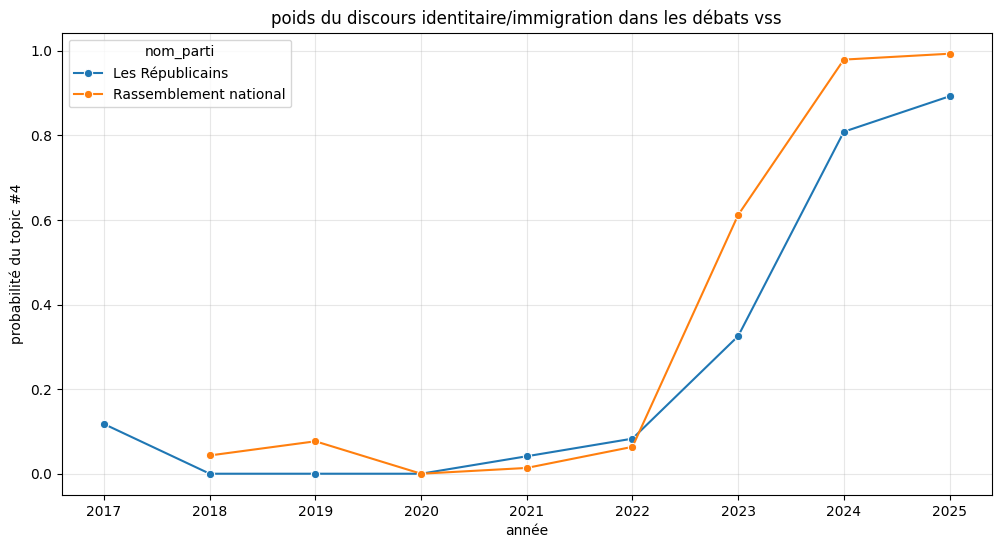

In [47]:
def extraire_poids_topic_specifique(lda_model, corpus, df_original, target_topic=4):
    ''' extrait les probabilités d'un topic spécifique pour chaque document '''
    poids_topic = []
    
    for bow in corpus:
        # on récupère la distribution des thèmes pour le document
        distribution = lda_model.get_document_topics(bow)
        # on cherche la probabilité du topic cible (par défaut le 4)
        prob = dict(distribution).get(target_topic, 0)
        poids_topic.append(prob)
    
    # ajout au dataframe
    df_res = df_original.copy()
    df_res['poids_identitaire'] = poids_topic
    return df_res

# exécution
df_evolution = extraire_poids_topic_specifique(lda, corpus, df_annuel)

# affichage du graphique de comparaison
import seaborn as sns

def tracer_convergence_lda(df):
    ''' compare l'évolution du topic identitaire entre lr et le rn '''
    # on se concentre sur les deux partis cibles
    partis_cibles = ["Les Républicains", "Rassemblement national"]
    data_plot = df[df['nom_parti'].isin(partis_cibles)]
    
    plt.figure(figsize=(12, 6))
    sns.lineplot(data=data_plot, x='periode', y='poids_identitaire', hue='nom_parti', marker='o')
    plt.title("poids du discours identitaire/immigration dans les débats vss")
    plt.ylabel("probabilité du topic #4")
    plt.xlabel("année")
    plt.grid(True, alpha=0.3)
    plt.show()

tracer_convergence_lda(df_evolution)

Sympa mais je pense que le topic 4 fit pas bien le topic immigration/sécurité, mais c'est déjà un début. 

Je vais faire le même graphe mais avec 5 bords poltiiques (en intégrant les partis dedans et en virant les trop petits partis ou les inclassables). 

In [48]:
def regrouper_blocs_ideologiques(nom_parti):
    ''' associe chaque parti à un bloc idéologique et gère les changements de noms '''
    # on met tout en minuscule pour éviter les erreurs de casse
    nom = str(nom_parti).lower()
    
    # 1. extrême droite
    if "rassemblement national" in nom or "front national" in nom or "udr" in nom:
        return "Extrême Droite"
    
    # 2. droite traditionnelle
    if "républicains" in nom:
        return "Droite Traditionnelle"
    
    # 3. centre (majorité présidentielle)
    centre = ["en marche", "république en marche", "renaissance", "ensemble", "modem", "mouvement démocrate", "horizons"]
    if any(c in nom for c in centre):
        return "Centre"
    
    # 4. gauche modérée
    gauche_m = ["socialiste", "écologistes - eelv", "europe écologie les verts", "radical de gauche"]
    if any(g in nom for g in gauche_m):
        return "Gauche Modérée"
    
    # 5. gauche radicale / extrême gauche
    gauche_r = ["france insoumise", "communiste", "lfi"]
    if any(g in nom for g in gauche_r):
        return "Gauche Radicale"
    
    # par défaut on renvoie none pour les partis à exclure (outre-mer, etc.)
    return None

# application du regroupement
df_evolution['bloc'] = df_evolution['nom_parti'].apply(regrouper_blocs_ideologiques)

# on supprime les lignes qui n'ont pas de bloc (les outres-mer et petits partis)
df_blocs = df_evolution.dropna(subset=['bloc']).copy()

In [49]:
def preparer_donnees_graphique(df):
    ''' calcule la moyenne de probabilité du topic identitaire par bloc et par an '''
    # on groupe par bloc et période, puis on fait la moyenne du poids du topic #4
    df_graph = df.groupby(['periode', 'bloc'])['poids_identitaire'].mean().reset_index()
    return df_graph

df_final_graph = preparer_donnees_graphique(df_blocs)

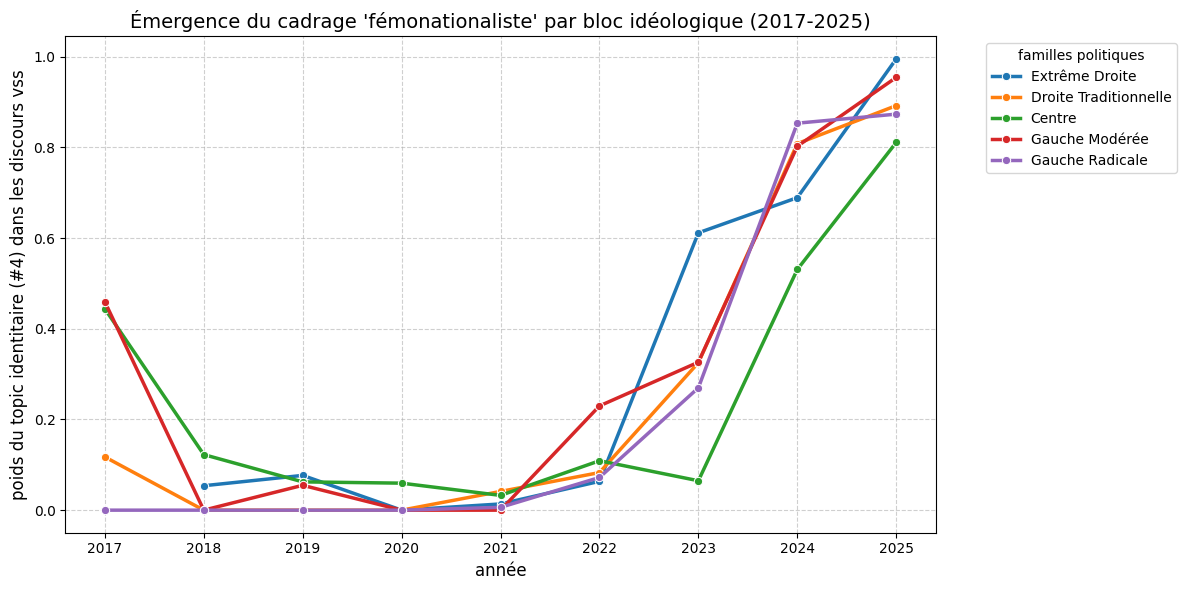

In [51]:
def tracer_5_courbes_ideologiques(df):
    ''' affiche l'évolution de la thématique identitaire pour les 5 blocs '''
    plt.figure(figsize=(12, 6))
    
    # on définit l'ordre des blocs pour la légende
    ordre_blocs = ["Extrême Droite", "Droite Traditionnelle", "Centre", "Gauche Modérée", "Gauche Radicale"]
    
    # création du graphique
    sns.lineplot(data=df, x='periode', y='poids_identitaire', 
                 hue='bloc', hue_order=ordre_blocs, 
                 marker='o', linewidth=2.5)
    
    # on retire les majuscules dans les commentaires
    # configuration esthétique
    plt.title("Émergence du cadrage 'fémonationaliste' par bloc idéologique (2017-2025)", fontsize=14)
    plt.ylabel("poids du topic identitaire (#4) dans les discours vss", fontsize=12)
    plt.xlabel("année", fontsize=12)
    plt.legend(title="familles politiques", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

# exécution
tracer_5_courbes_ideologiques(df_final_graph)

## Similarité cosinus test

In [55]:
from gensim.models import Word2Vec

def entrainer_espaces_semantiques(df_clean):
    ''' entraîne le modèle word2vec pour transformer chaque mot en un vecteur de 100 chiffres '''
    # on prépare les listes de mots pour l'algo
    phrases = [str(doc).split() for doc in df_clean['texte_clean']]
    
    # entraînement : vector_size=100 veut dire 100 dimensions
    # window=5 : on regarde le contexte autour de chaque mot
    model = Word2Vec(sentences=phrases, vector_size=100, window=5, min_count=2, workers=4)
    return model


model_w2v = entrainer_espaces_semantiques(df_annuel)
print("exécution terminée")

exécution terminée


In [59]:
def calculer_vecteur_moyen(texte, model):
    ''' calcule la position moyenne d'un texte dans l'espace sémantique '''
    mots = str(texte).split()
    # on ne garde que les mots que l'algo connaît
    vecteurs = [model.wv[m] for m in mots if m in model.wv]
    
    if not vecteurs:
        return np.zeros(model.vector_size)
    
    # on fait la moyenne de tous les mots du texte
    return np.mean(vecteurs, axis=0)

In [60]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

def analyser_contagion_cosinus(df, model):
    ''' compare chaque bloc à l'extrême droite année par année '''
    resultats = []
    
    # on commence par calculer tous les vecteurs pour chaque ligne du df
    df['vecteur'] = df['texte_clean'].apply(lambda x: calculer_vecteur_moyen(x, model))
    
    for annee in sorted(df['periode'].unique()):
        df_an = df[df['periode'] == annee]
        
        # on récupère le vecteur de référence (l'extrême droite)
        if "Extrême Droite" in df_an['bloc'].values:
            vec_ed = list(df_an[df_an['bloc'] == "Extrême Droite"]['vecteur'])[0]
            
            for bloc in df_an['bloc'].unique():
                if bloc == "Extrême Droite": continue
                
                vec_cible = list(df_an[df_an['bloc'] == bloc]['vecteur'])[0]
                # calcul de la similarité cosinus
                sim = cosine_similarity([vec_ed], [vec_cible])[0][0]
                
                resultats.append({'annee': annee, 'bloc': bloc, 'similarite': sim})
    
    return pd.DataFrame(resultats)

# exécution
df_sim = analyser_contagion_cosinus(df_blocs, model_w2v)
print("terminé")

terminé


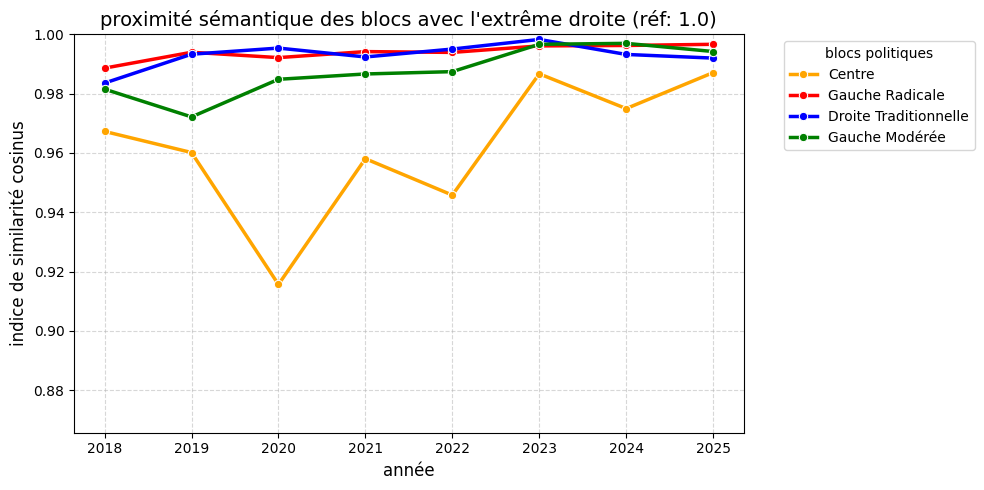

In [62]:
def tracer_graphique_similarite(df):
    ''' dessine l'évolution de la proximité sémantique avec l'extrême droite '''
    # on vérifie si le dataframe n'est pas vide
    if df.empty:
        print("le tableau de similarité est vide.")
        return

    plt.figure(figsize=(10, 5))
    
    # on définit les couleurs pour que ce soit clair
    palette_couleurs = {
        "Droite Traditionnelle": "blue",
        "Centre": "orange",
        "Gauche Modérée": "green",
        "Gauche Radicale": "red"
    }

    # création du graphique
    sns.lineplot(data=df, x='annee', y='similarite', hue='bloc', 
                 palette=palette_couleurs, marker='o', linewidth=2.5)

    # réglages du graphique
    plt.title("proximité sémantique des blocs avec l'extrême droite (réf: 1.0)", fontsize=14)
    plt.ylabel("indice de similarité cosinus", fontsize=12)
    plt.xlabel("année", fontsize=12)
    plt.legend(title="blocs politiques", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.5)
    
    # on fixe l'échelle pour mieux voir les variations
    plt.ylim(df['similarite'].min() - 0.05, 1.0)
    
    plt.tight_layout()
    plt.show()

# on appelle la fonction
tracer_graphique_similarite(df_sim)

Bon on va tenter une autre approche parce que le topic 4 était pas très concluant pour l'instant, on va un peu "forcer" le topic et voir les convergences dessus

In [67]:
def creer_vecteur_concept(model, mots_clefs):
    ''' crée un vecteur de référence unique à partir d'une liste de mots idéologiques '''
    vecteurs = [model.wv[m] for m in mots_clefs if m in model.wv]
    # on fait la moyenne pour avoir le "centre de gravité" du concept
    return np.mean(vecteurs, axis=0)

# on définit les mots qui marquent la "contagion" selon ta thèse
mots_identitaires = ["immigr", "clandestin", "fronti", "national", "identit", "cultur", "étranger", "expuls", "valeur"]
vecteur_ref = creer_vecteur_concept(model_w2v, [stemmer.stem(m) for m in mots_identitaires])
print(".")

.


In [68]:
def filtrage_strict_intersection(df, liste_vss, liste_identitaire):
    ''' ne garde que les paragraphes où les deux thématiques se croisent (le coeur du sujet) '''
    pattern_vss = '|'.join(liste_vss)
    pattern_id = '|'.join(liste_identitaire)
    
    # on cherche les lignes qui ont les deux signaux
    mask = (df['texte'].str.contains(pattern_vss, case=False, na=False)) & \
           (df['texte'].str.contains(pattern_id, case=False, na=False))
    
    return df[mask].copy()

# on crée le corpus "coeur de cible"
df_coeur = filtrage_strict_intersection(df_global, a_tester, mots_identitaires)
print(".")

.


In [71]:
def mesurer_derive_vers_concept(df, model, vecteur_ref):
    ''' calcule la similarité de chaque bloc par rapport au concept d'immigration '''
    resultats = []
    
    # on regroupe par bloc et année
    df_annuel = df.groupby(['periode', 'bloc'])['texte_clean'].apply(lambda x: ' '.join(x)).reset_index()
    
    for _, row in df_annuel.iterrows():
        vec_parti = calculer_vecteur_moyen(row['texte_clean'], model)
        
        # distance entre le discours du parti et le concept "immigration"
        sim = cosine_similarity([vec_parti], [vecteur_ref])[0][0]
        
        resultats.append({
            'annee': row['periode'],
            'bloc': row['bloc'],
            'proximite_identitaire': sim
        })
        
    return pd.DataFrame(resultats)

# exécution
#
df_annuel_blocs = df_blocs.groupby(['periode', 'bloc'])['texte_clean'].apply(lambda x: ' '.join(x)).reset_index()

df_derive = mesurer_derive_vers_concept(df_annuel_blocs, model_w2v, vecteur_ref)
print("!")

!


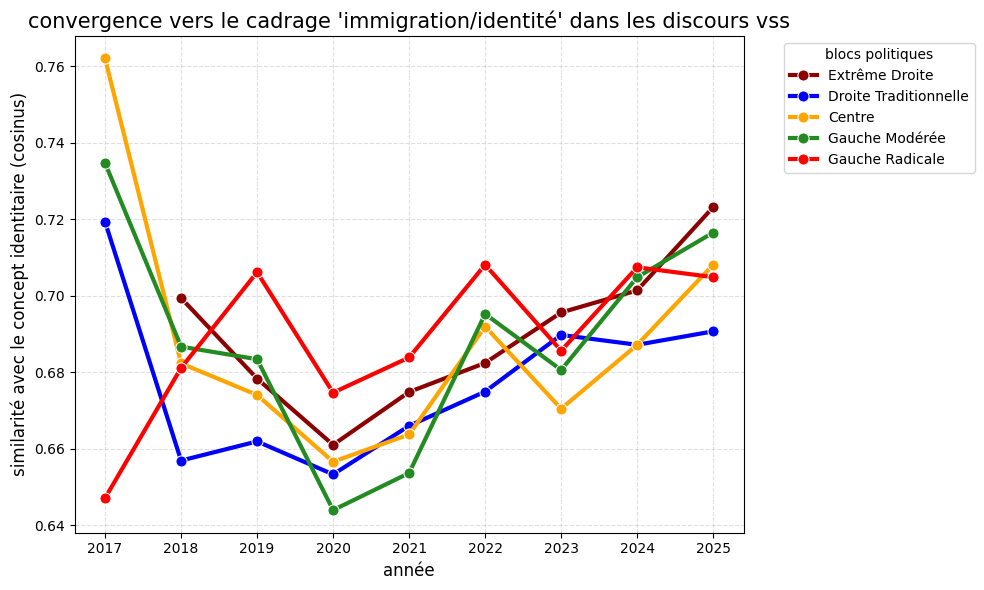

In [73]:
def tracer_derive_concept_identitaire(df):
    ''' génère le graphique montrant comment chaque bloc se rapproche du concept immigration/identité '''
    # on s'assure que les données sont triées par année
    df = df.sort_values('annee')
    
    plt.figure(figsize=(10, 6))
    
    # on définit des couleurs explicites pour les 5 familles
    couleurs = {
        "Extrême Droite": "#8B0000",       # rouge foncé
        "Droite Traditionnelle": "#0000FF", # bleu
        "Centre": "#FFA500",               # orange
        "Gauche Modérée": "#228B22",       # vert forêt
        "Gauche Radicale": "#FF0000"        # rouge vif
    }
    
    # on définit l'ordre pour la légende
    ordre = ["Extrême Droite", "Droite Traditionnelle", "Centre", "Gauche Modérée", "Gauche Radicale"]

    # création de la courbe
    sns.lineplot(data=df, x='annee', y='proximite_identitaire', 
                 hue='bloc', hue_order=ordre, 
                 palette=couleurs, marker='o', linewidth=3, markersize=8)

    # habillage du graphique
    # on n'oublie pas : pas de majuscules dans les commentaires
    plt.title("convergence vers le cadrage 'immigration/identité' dans les discours vss", fontsize=15)
    plt.ylabel("similarité avec le concept identitaire (cosinus)", fontsize=12)
    plt.xlabel("année", fontsize=12)
    
    # placement de la légende
    plt.legend(title="blocs politiques", bbox_to_anchor=(1.05, 1), loc='upper left')
    
    # on ajoute une grille pour lire plus facilement les évolutions
    plt.grid(True, linestyle='--', alpha=0.4)
    
    # on ajuste les marges pour ne pas couper la légende
    plt.tight_layout()
    plt.show()

# on lance l'affichage
tracer_derive_concept_identitaire(df_derive)
